# A3a — one network for legs A, B and C

This notebook only **loads** what the scripts wrote. Nothing here recomputes a
network, a reference or a score; the numbers come from `results/` and the
figures from `figures/`.

| script | output |
|---|---|
| `build_dataset.py` | `results/general_legs.npz`, `results/dataset_meta.json` |
| `_shared/train.py` (26 farm jobs) | `results/<tag>.json`, `<tag>.pt`, `<tag>_history.csv` |
| `aggregate.py` | `results/summary.csv`, `results/by_leg.csv`, `results/stage_errors.csv` |
| `plot.py` | the three figures |


In [1]:
import json
import pandas as pd
from IPython.display import Image, display

meta = json.load(open("results/dataset_meta.json"))
print("training states:", meta["n_train_chosen"], "->", meta["counts"])
print("per leg:", meta["per_leg"]["train"])
pd.DataFrame(meta["timing_table"])

training states: 8000 -> {'train': 7935, 'val': 3969, 'test': 3961}
per leg: {'A': 1317, 'B': 1060, 'C': 5558, 'D': 0}


,n_train_cap,n_rows_timed,restart_s,process_s,projected_150_restarts_h,under_budget
0,2000,2000,13.8,19.8,0.57,True
1,4000,4000,26.8,32.3,1.12,True
2,8000,8000,47.3,53.3,1.97,True
3,16000,15853,97.1,103.8,4.05,False


## How long one L-BFGS restart takes, and therefore how big the training set is

In [2]:
pd.DataFrame(meta["momentum_mix"]["train"]).T

,1-5GeV,5-20GeV,20-200GeV,p_median_GeV
A,722.0,413.0,182.0,4.412760
B,385.0,495.0,180.0,7.375465
C,3177.0,1791.0,590.0,4.013754


The builder caps the pool with a plain random permutation, so the momentum
mix above is the training set's own mix, recorded rather than imposed.

## The runs

In [3]:
summary = pd.read_csv("results/summary.csv")
summary[["tag", "mode", "seed", "width", "restarts", "converged", "final_loss",
         "test_endpoint_med_um", "test_endpoint_p95_um", "wall_s"]].sort_values(
    ["width", "mode", "seed"])

,tag,mode,seed,width,restarts,converged,final_loss,test_endpoint_med_um,test_endpoint_p95_um,wall_s
26,w50_data_s0,data,0,50,114,True,0.000054,607.355971,8621.803911,1650.3
27,w50_data_s1,data,1,50,107,True,0.000059,636.598544,9223.778119,1561.8
28,w50_data_s2,data,2,50,117,True,0.000055,645.107025,8859.683572,1718.3
29,w50_physics_s0,physics,0,50,88,True,0.000080,841.820965,18567.857697,1360.8
30,w50_physics_s1,physics,1,50,93,True,0.000073,716.661251,17598.109920,2315.9
31,w50_physics_s2,physics,2,50,55,True,0.000139,1178.508420,27301.712662,786.9
32,w50_physics_s3,physics,3,50,59,True,0.000146,935.452887,27260.291769,1436.2
33,w50_physics_s4,physics,4,50,82,True,0.000072,649.403451,19633.311975,1301.3
34,w50_physics_s5,physics,5,50,68,True,0.000104,717.742849,22662.371132,1720.3
35,w50_physics_s6,physics,6,50,65,True,0.000104,671.940001,19610.705138,1093.8


## Leg by leg, against the exact-scheme ceiling

In [4]:
by_leg = pd.read_csv("results/by_leg.csv")
t = by_leg[(by_leg.split == "test") & (by_leg.band == "all") & by_leg.converged]
tab = t.pivot_table(index=["leg"], columns=["width", "mode"],
                    values="endpoint_med_um", aggfunc="median")
tab["straight_um"] = t.groupby("leg").straight_med_um.median()
tab["ceiling_q8_um"] = t.groupby("leg").ceiling_leg_um.first()
tab

width           50                      100                      200  \
mode          data      physics        data      physics        data   
leg                                                                    
A       652.918844   848.609402  384.774418   404.211604  226.922387   
B      2394.688216  6741.987698  933.283267  2599.942685  776.703499   
C       485.913813   534.983419  235.242456   299.543349  181.663410   

width                 straight_um ceiling_q8_um  
mode       physics                               
leg                                              
A       228.790836      10.945522      0.000744  
B      1740.310797  444074.609859     29.066263  
C       212.712888       6.633685      0.000002

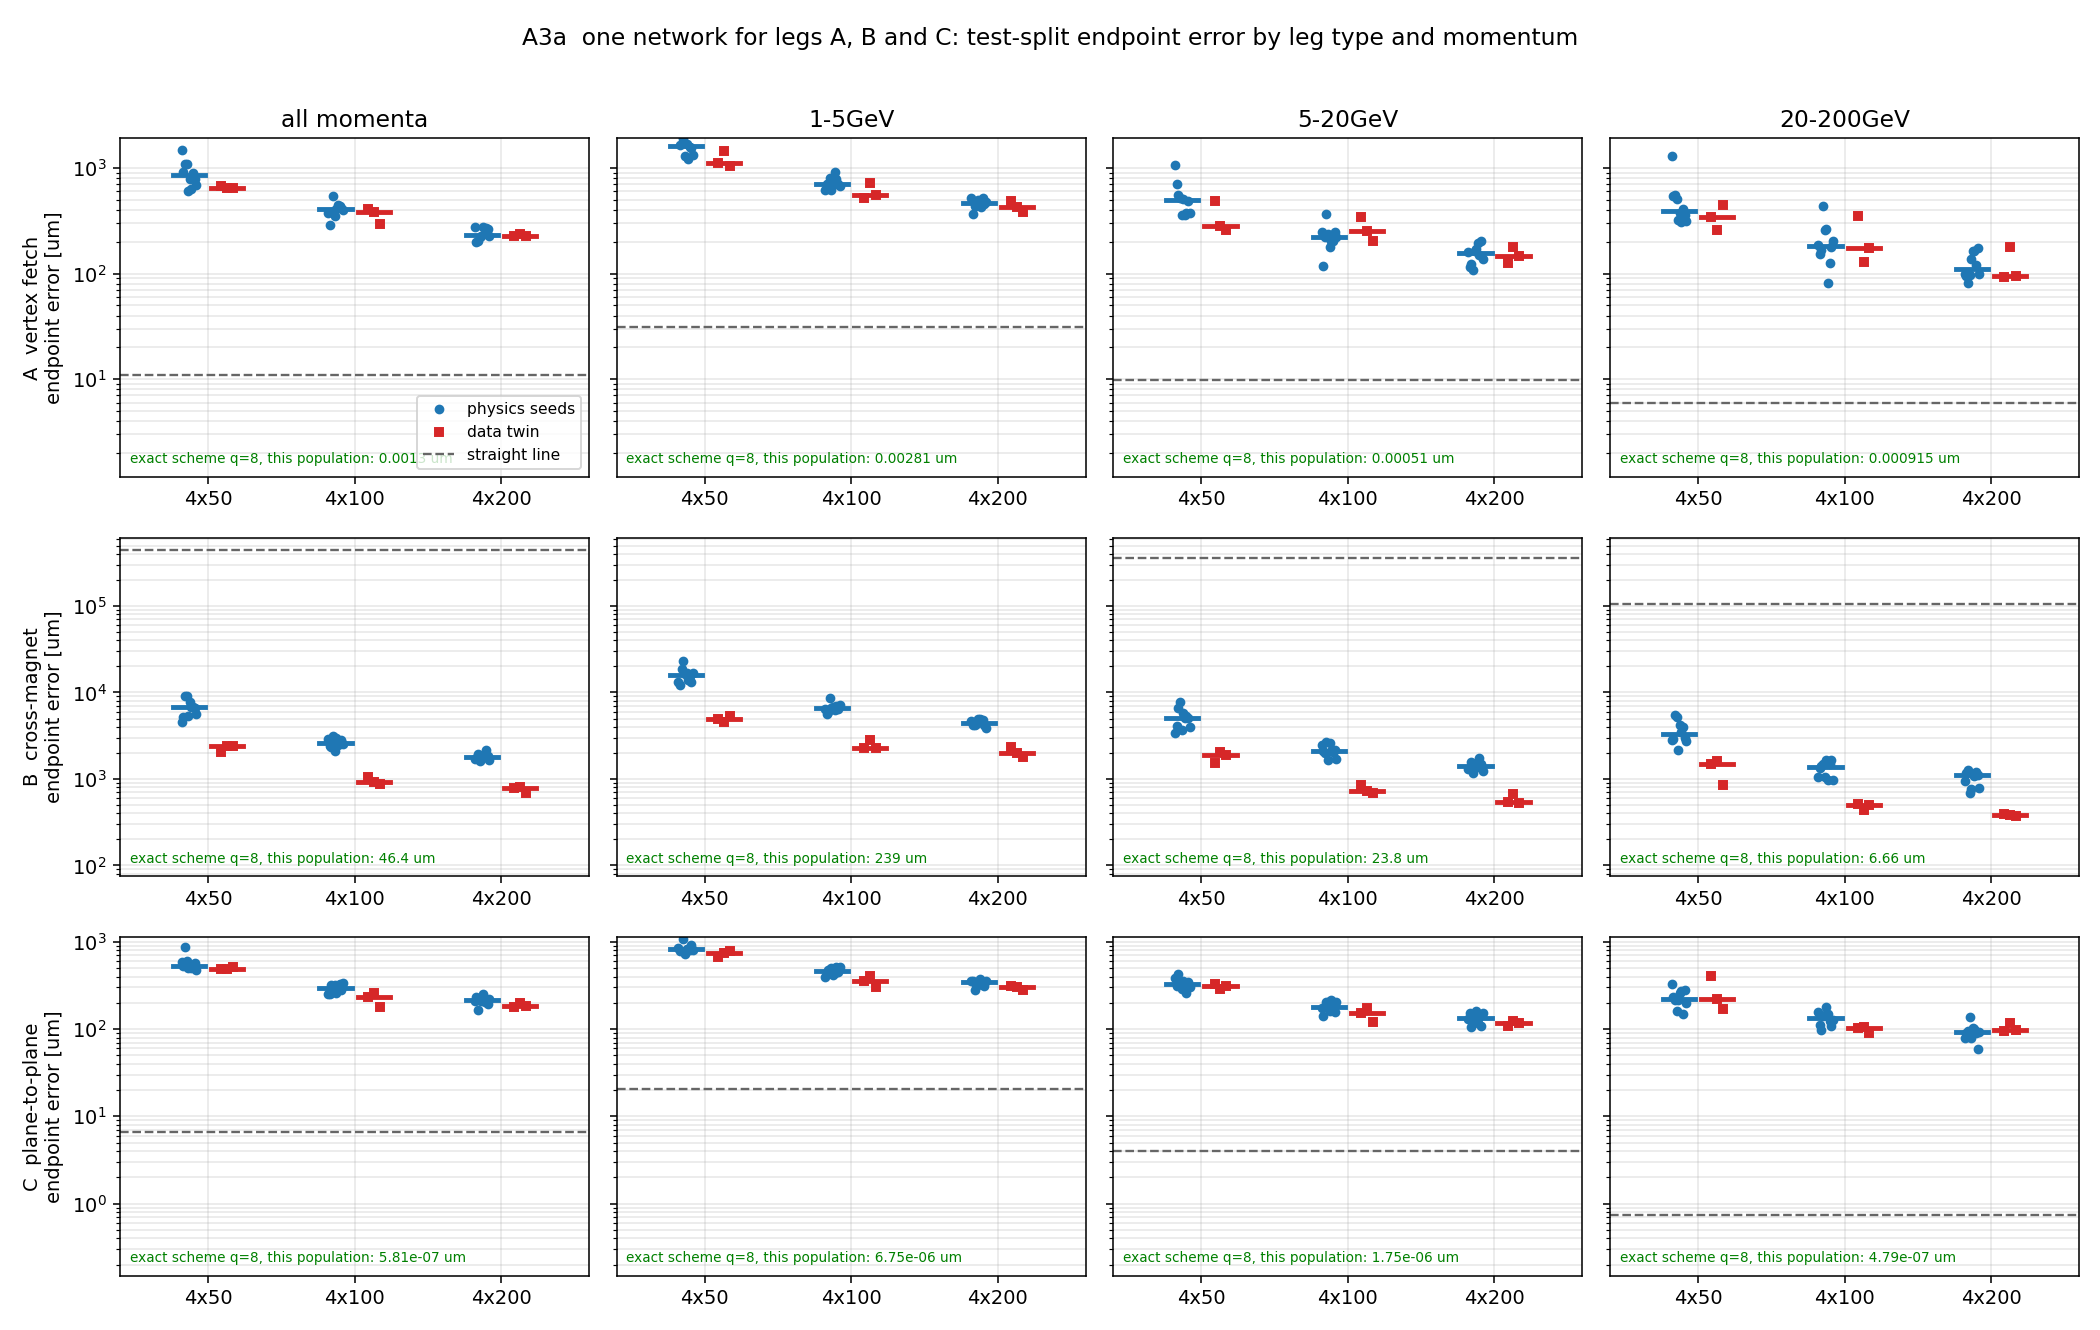

In [5]:
display(Image("figures/error_by_leg_and_momentum.png"))

## The error along the step, not only at its end

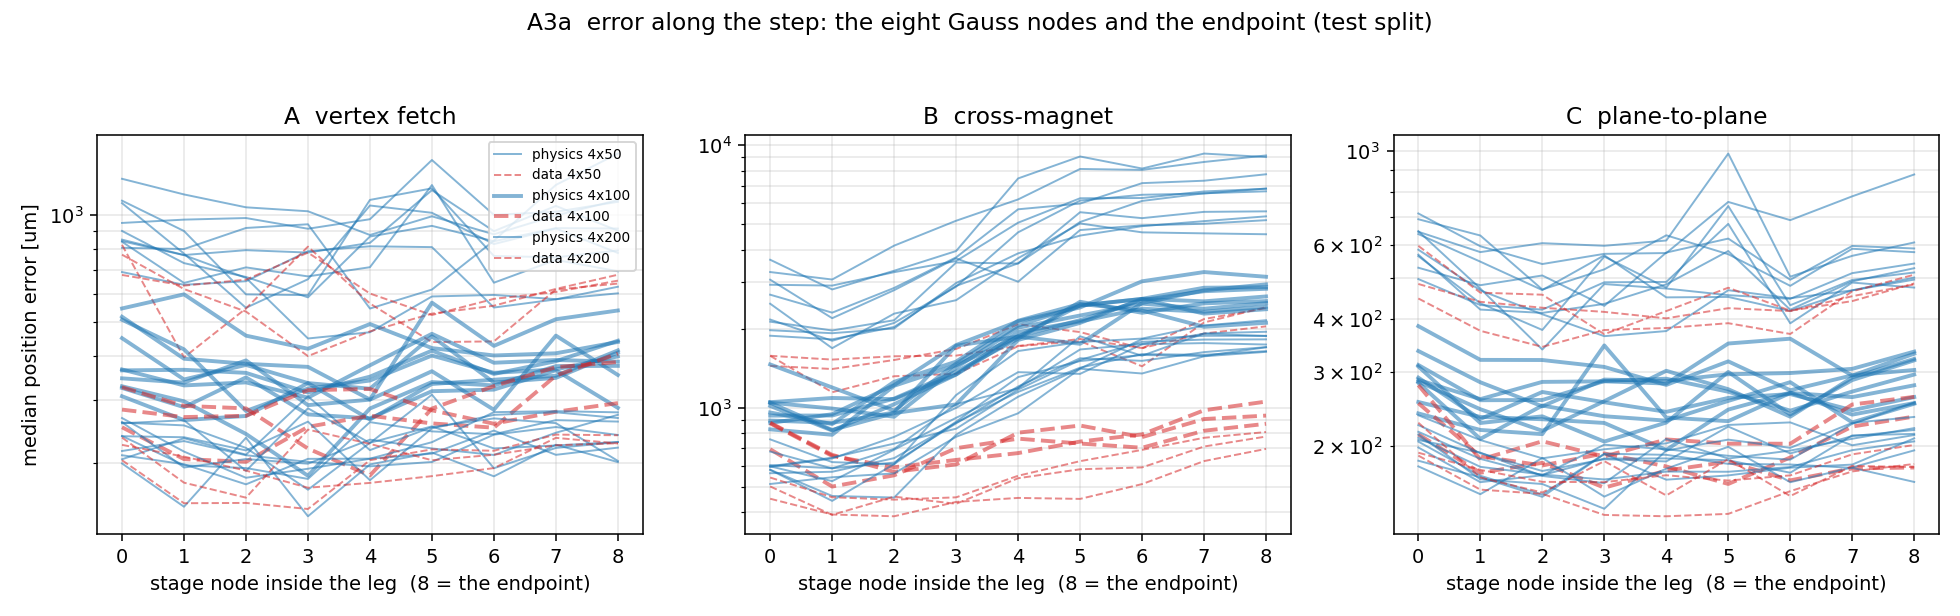

In [6]:
display(Image("figures/stage_errors.png"))

## The cross-magnet leg: frozen leg vs one network for everything

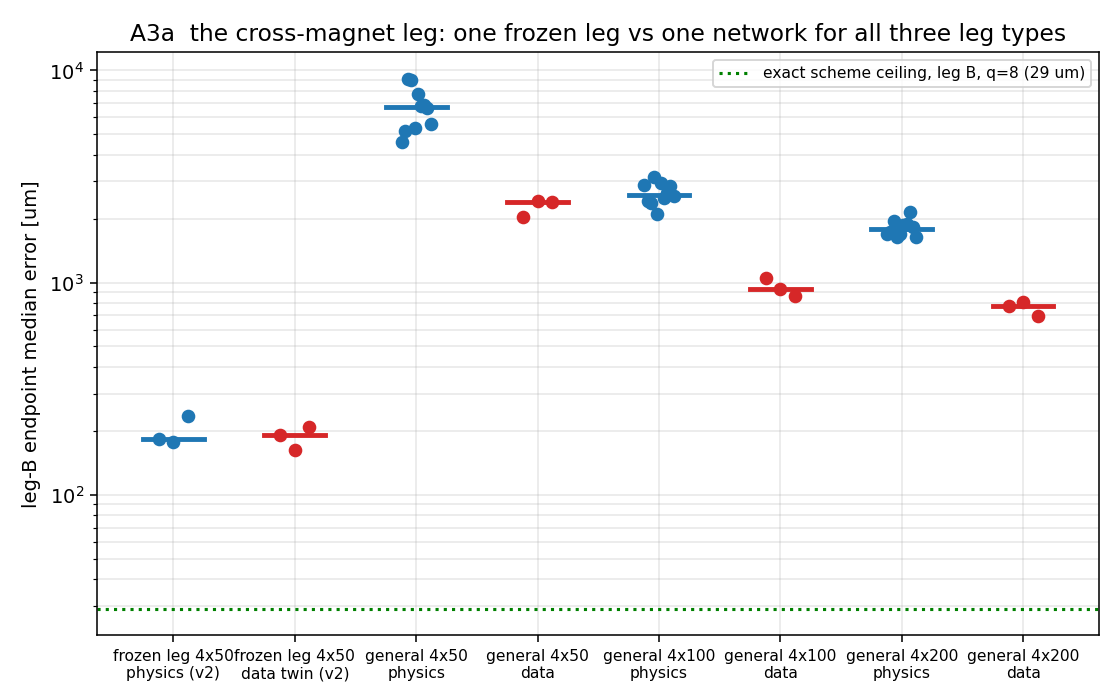

In [7]:
display(Image("figures/frozen_vs_general.png"))